#### Persiapan Pelatihan Model

Tahap ini bertujuan untuk mempersiapkan seluruh kebutuhan sebelum proses pelatihan model LightGBM dilakukan. Pada tahap ini dilakukan pemuatan dataset hasil *feature engineering*, konfigurasi eksperimen dari notebook sebelumnya, serta inisialisasi parameter umum seperti direktori penyimpanan, *random seed*, dan pengaturan visualisasi. Selain itu, dataset diurutkan berdasarkan waktu dan lokasi untuk memastikan konsistensi struktur data panel sebelum digunakan pada proses pelatihan dan evaluasi model.

In [18]:
# Import library dan konfigurasi eksperimen

import json
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit,
)


# Atur konfigurasi output, visualisasi, dan reproducibility

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Tentukan folder input dan output eksperimen

DIR_PROCESSED = Path("../data/processed")
DIR_MODELS = Path("../models")
DIR_RESULTS = Path("../data/results")

DIR_MODELS.mkdir(
    parents=True,
    exist_ok=True,
)

DIR_RESULTS.mkdir(
    parents=True,
    exist_ok=True,
)


# Muat konfigurasi feature engineering

config_path = (
    DIR_PROCESSED /
    "feature_config.json"
)

if not config_path.exists():

    raise FileNotFoundError(
        f"File konfigurasi tidak ditemukan: {config_path}"
    )

with open(
    config_path,
    encoding="utf-8",
) as file:

    CONFIG = json.load(file)


# Ambil konfigurasi utama dan periode eksperimen

TARGET = CONFIG["target"]
FEATURE_SET = CONFIG["feature_sets"]

SPLIT_COLUMN = CONFIG["split"]["column"]

TRAIN_YEARS = CONFIG["split"]["train_years"]
TEST_YEARS = CONFIG["split"]["test_years"]


# Muat dataset hasil feature engineering

feature_dataset_path = (
    DIR_PROCESSED /
    CONFIG["dataset_file"]
)

csv_dataset_path = (
    DIR_PROCESSED /
    "features_dataset.csv"
)

if feature_dataset_path.exists():

    data = pd.read_parquet(
        feature_dataset_path,
    )

else:

    data = pd.read_csv(
        csv_dataset_path,
        parse_dates=["date"],
    )

data["date"] = pd.to_datetime(
    data["date"]
)


# Urutkan dataset berdasarkan waktu dan lokasi

data = (
    data.sort_values(
        [
            "date",
            "location_id",
        ]
    )
    .reset_index(drop=True)
)


# Tampilkan ringkasan dataset dan konfigurasi eksperimen

print(f"Dataset      : {feature_dataset_path.name}")
print(f"Jumlah baris : {len(data):,}")
print(f"Target       : {TARGET}")

print("\nSkenario fitur")

for scenario_name, feature_list in FEATURE_SET.items():

    print(
        f"{scenario_name:<6}: "
        f"{len(feature_list)} fitur"
    )

print(
    f"\nSplit data   : "
    f"Train {TRAIN_YEARS} | "
    f"Test {TEST_YEARS}"
)

print(f"Folder model : {DIR_MODELS.resolve()}")
print(f"Folder hasil : {DIR_RESULTS.resolve()}")

Dataset      : features_dataset.parquet
Jumlah baris : 73,040
Target       : GHI

Skenario fitur
METEO : 11 fitur
FULL  : 13 fitur

Split data   : Train [2021, 2022, 2023, 2024] | Test [2025]
Folder model : C:\Users\Z00588HW\OneDrive - Siemens AG\tugas-akhir-angga\ml\models
Folder hasil : C:\Users\Z00588HW\OneDrive - Siemens AG\tugas-akhir-angga\ml\data\results


## Pembagian Data Pelatihan dan Pengujian

Tahap ini bertujuan membagi dataset menjadi data pelatihan dan data pengujian berdasarkan urutan waktu agar proses pelatihan mengikuti kondisi nyata pada permasalahan prediksi deret waktu.

Data tahun 2021–2024 digunakan sebagai data pelatihan, sedangkan data tahun 2025 digunakan sebagai data pengujian. Selain itu, data tahun 2024 dipisahkan sebagai data validasi internal yang digunakan pada proses *early stopping* untuk menentukan jumlah iterasi boosting terbaik tanpa melibatkan data pengujian.

In [19]:
# Tentukan tahun validasi internal dan subset data

VALIDATION_YEAR = max(
    TRAIN_YEARS
)

train_mask = (
    data[SPLIT_COLUMN] == "train"
)

test_mask = (
    data[SPLIT_COLUMN] == "test"
)

fit_mask = (
    train_mask
    & (data["year"] < VALIDATION_YEAR)
)

validation_mask = (
    train_mask
    & (data["year"] == VALIDATION_YEAR)
)


# Susun dataset berdasarkan subset dan skenario fitur

def build_dataset(feature_list):
    """
    Menyusun dataset berdasarkan daftar fitur
    untuk setiap subset pelatihan dan pengujian.
    """

    X = data[feature_list]
    y = data[TARGET]

    return {

        "X_train": X[train_mask],
        "y_train": y[train_mask],

        "X_fit": X[fit_mask],
        "y_fit": y[fit_mask],

        "X_val": X[validation_mask],
        "y_val": y[validation_mask],

        "X_test": X[test_mask],
        "y_test": y[test_mask],
    }


# Ringkas pembagian data untuk setiap subset

split_summary = pd.DataFrame({

    "Subset": [
        "Fit",
        "Validation",
        "Train",
        "Test",
    ],

    "Years": [
        "2021–2023",
        f"{VALIDATION_YEAR}",
        "2021–2024",
        "2025",
    ],

    "Rows": [
        fit_mask.sum(),
        validation_mask.sum(),
        train_mask.sum(),
        test_mask.sum(),
    ],
})


# Tampilkan ringkasan pembagian data

display(split_summary)

,Subset,Years,Rows
0,Fit,2021–2023,43800
1,Validation,2024,14640
2,Train,2021–2024,58440
3,Test,2025,14600


## Hyperparameter Tuning

Tahap ini bertujuan memperoleh konfigurasi hyperparameter yang mampu meningkatkan kemampuan generalisasi model sekaligus mengurangi risiko *overfitting*.

Penelitian ini melakukan optimasi terhadap **tiga hyperparameter**, yaitu `learning_rate`, `num_leaves`, dan `min_child_samples`. Parameter `learning_rate` mengendalikan laju pembelajaran (*shrinkage*) pada setiap iterasi boosting, sedangkan `num_leaves` dan `min_child_samples` secara langsung mengendalikan kompleksitas struktur pohon keputusan pada LightGBM. Karena LightGBM tumbuh secara *leaf-wise*, kompleksitas pohon dikendalikan langsung oleh `num_leaves` sehingga `max_depth` dibiarkan pada nilai bawaan (tanpa batas). Pemilihan ketiga hyperparameter ini menjaga kesetaraan dengan `learning_rate`, `max_depth`, dan `min_child_weight` pada XGBoost, di mana `num_leaves` sepadan dengan $2^{max\_depth}$ dan `min_child_samples` setara dengan `min_child_weight`. Sementara itu, hyperparameter lainnya dipertahankan pada nilai bawaan (*default*) agar ruang pencarian tetap efisien dan proses komparasi dengan algoritma XGBoost dilakukan secara adil.

Proses pencarian kombinasi hyperparameter terbaik dilakukan menggunakan Grid Search yang dipadukan dengan *TimeSeriesSplit* menggunakan metrik RMSE sebagai fungsi evaluasi.


In [ ]:
# Fungsi evaluasi model regresi
def calculate_regression_metrics(
    y_true,
    y_pred,
):
    """
    Menghitung metrik evaluasi regresi
    berupa RMSE, MAE, dan R².
    """

    return {

        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred,
                )
            )
        ),

        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),

        "R2": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
    }

PARAM_GRID = {

    "num_leaves": [
        15,
        31,
        45,
    ],

    "min_child_samples": [
        100,
        200,
        300,
    ],

    "min_gain_to_split": [
        0.05,
        0.1,
        0.3,
    ],
}

# Jumlah fold untuk TimeSeriesSplit
N_SPLITS = 5

def tune_lightgbm(
    X_train,
    y_train,
):
    """
    Melakukan hyperparameter tuning LightGBM
    menggunakan GridSearchCV dan TimeSeriesSplit.
    """

    # Inisialisasi model dasar
    # learning_rate ditetapkan di sini agar
    # konsisten dengan scouting dan final model
    model = lgb.LGBMRegressor(
        objective="regression",
        learning_rate=LEARNING_RATE,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )

    # Cross-validation khusus data deret waktu
    time_series_cv = TimeSeriesSplit(
        n_splits=N_SPLITS,
    )

    # Grid Search seluruh kombinasi parameter
    search = GridSearchCV(
        estimator=model,
        param_grid=PARAM_GRID,
        scoring="neg_root_mean_squared_error",
        cv=time_series_cv,
        n_jobs=-1,
        refit=False,
        verbose=0,
    )

    # Jalankan proses tuning
    search.fit(
        X_train,
        y_train,
    )

    # Ambil kombinasi parameter terbaik
    best_params = (
        search.best_params_
    )

    # Ambil RMSE terbaik hasil cross-validation
    best_cv_rmse = float(
        -search.best_score_
    )

    return (
        best_params,
        best_cv_rmse,
    )

# Hitung jumlah kombinasi hyperparameter
total_combination = (
    len(PARAM_GRID["num_leaves"])
    * len(PARAM_GRID["min_child_samples"])
    * len(PARAM_GRID["min_gain_to_split"])
)

# Tampilkan ringkasan konfigurasi tuning
print("Fungsi evaluasi dan hyperparameter tuning siap.")
print(f"Jumlah fold CV        : {N_SPLITS}")
print(f"Total kombinasi uji   : {total_combination}")
print(
    f"Total proses training : "
    f"{total_combination * N_SPLITS}"
)

Fungsi evaluasi dan hyperparameter tuning siap.
Jumlah fold CV        : 5
Total kombinasi uji   : 27
Total proses training : 135


## Pelatihan Model LightGBM

Tahap ini bertujuan untuk melatih model LightGBM pada setiap skenario fitur yang telah ditentukan. Proses pelatihan diawali dengan hyperparameter tuning menggunakan GridSearchCV, kemudian dilanjutkan dengan pencarian jumlah boosting optimal melalui mekanisme early stopping menggunakan data validasi tahun 2024. Setelah jumlah boosting terbaik diperoleh, model dilatih kembali menggunakan seluruh data pelatihan (2021–2024) dan selanjutnya dievaluasi pada data pengujian tahun 2025.

In [21]:
# Learning rate ditetapkan secara eksplisit
# di luar grid agar konsisten di seluruh tahap
LEARNING_RATE = 0.01

# Konfigurasi early stopping
# Diperbesar proporsional terhadap learning rate
# yang kecil untuk menghindari penghentian prematur
EARLY_STOPPING_ROUNDS = 100

# Jumlah maksimum boosting iteration
# Diperbesar untuk memberi ruang konvergensi
# yang cukup pada learning rate kecil
MAX_BOOSTING_ROUNDS = 5000

def train_scenario(
    scenario_name,
    feature_list,
):
    """
    Melatih satu skenario fitur menggunakan LightGBM.
    """

    print(
        f"\n{'=' * 60}"
        f"\nSKENARIO: {scenario_name}"
        f" ({len(feature_list)} fitur)"
        f"\n{'=' * 60}"
    )

    # Susun dataset sesuai skenario
    dataset = build_dataset(
        feature_list,
    )

    # Hyperparameter tuning
    best_params, best_cv_rmse = tune_lightgbm(
        dataset["X_train"],
        dataset["y_train"],
    )

    print(
        f"CV RMSE        : "
        f"{best_cv_rmse:.4f}"
    )

    print(
        f"Best parameter : "
        f"{best_params}"
    )

    # Model sementara untuk mencari
    # jumlah boosting iteration terbaik
    scouting_model = lgb.LGBMRegressor(

        objective="regression",
        learning_rate=LEARNING_RATE,

        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,

        n_estimators=MAX_BOOSTING_ROUNDS,

        **best_params,
    )

    scouting_model.fit(

        dataset["X_fit"],
        dataset["y_fit"],

        eval_set=[
            (
                dataset["X_val"],
                dataset["y_val"],
            )
        ],

        eval_metric="rmse",

        callbacks=[
            lgb.early_stopping(
                EARLY_STOPPING_ROUNDS,
                verbose=False,
            )
        ],
    )

    # Ambil boosting iteration terbaik
    best_iteration = (
        scouting_model.best_iteration_
    )

    print(
        f"Best iteration : "
        f"{best_iteration}"
    )

    # Latih model akhir menggunakan
    # seluruh data training
    final_model = lgb.LGBMRegressor(

        objective="regression",
        learning_rate=LEARNING_RATE,

        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,

        n_estimators=best_iteration,

        **best_params,
    )

    final_model.fit(

        dataset["X_train"],
        dataset["y_train"],
    )

    # Prediksi data train dan test
    train_prediction = final_model.predict(
        dataset["X_train"]
    )

    test_prediction = final_model.predict(
        dataset["X_test"]
    )

    # Hitung metrik evaluasi
    train_metrics = calculate_regression_metrics(
        dataset["y_train"],
        train_prediction,
    )

    test_metrics = calculate_regression_metrics(
        dataset["y_test"],
        test_prediction,
    )

    # Tampilkan hasil evaluasi
    print(
        f"TRAIN | "
        f"RMSE={train_metrics['RMSE']:.4f} | "
        f"MAE={train_metrics['MAE']:.4f} | "
        f"R²={train_metrics['R2']:.4f}"
    )

    print(
        f"TEST  | "
        f"RMSE={test_metrics['RMSE']:.4f} | "
        f"MAE={test_metrics['MAE']:.4f} | "
        f"R²={test_metrics['R2']:.4f}"
    )

    return {

        "name": scenario_name,

        "features": feature_list,

        "model": final_model,

        "best_params": best_params,

        "best_iteration": int(
            best_iteration
        ),

        "cv_rmse": best_cv_rmse,

        "metrics_train": train_metrics,

        "metrics_test": test_metrics,

        "y_test": dataset["y_test"].to_numpy(),

        "pred_test": test_prediction,

        "test_index": (
            data.loc[
                test_mask,
                [
                    "location_id",
                    "date",
                ],
            ]
            .reset_index(drop=True)
        ),
    }

# Latih seluruh skenario
results = {

    scenario_name: train_scenario(
        scenario_name,
        feature_list,
    )

    for scenario_name, feature_list
    in FEATURE_SET.items()
}

print(
    "\nSeluruh skenario LightGBM berhasil dilatih."
)


SKENARIO: METEO (11 fitur)
CV RMSE        : 1.0790
Best parameter : {'min_child_samples': 300, 'min_gain_to_split': 0.1, 'num_leaves': 45}
Best iteration : 316
TRAIN | RMSE=0.9169 | MAE=0.6791 | R²=0.4631
TEST  | RMSE=1.0516 | MAE=0.7883 | R²=0.2765

SKENARIO: FULL (13 fitur)
CV RMSE        : 0.5428
Best parameter : {'min_child_samples': 100, 'min_gain_to_split': 0.05, 'num_leaves': 45}
Best iteration : 812
TRAIN | RMSE=0.1530 | MAE=0.1117 | R²=0.9851
TEST  | RMSE=0.2147 | MAE=0.1278 | R²=0.9698

Seluruh skenario LightGBM berhasil dilatih.


#### Ringkasan Hasil Pelatihan Model

Tahap ini bertujuan untuk menyusun ringkasan hasil pelatihan pada setiap skenario fitur. Informasi yang ditampilkan meliputi jumlah fitur, nilai RMSE hasil cross-validation, metrik evaluasi pada data pelatihan dan pengujian, serta jumlah boosting iteration terbaik yang diperoleh melalui early stopping. Ringkasan ini digunakan sebagai dasar untuk membandingkan performa antar skenario sebelum dilakukan analisis yang lebih mendalam.

In [22]:
# Susun ringkasan hasil pelatihan setiap skenario
summary_rows = []

for scenario_name, result in results.items():

    summary_rows.append({

        "scenario": scenario_name,

        "n_features": len(
            result["features"]
        ),

        "cv_rmse": round(
            result["cv_rmse"],
            4,
        ),

        "best_iteration": result[
            "best_iteration"
        ],

        "train_rmse": round(
            result["metrics_train"]["RMSE"],
            4,
        ),

        "test_rmse": round(
            result["metrics_test"]["RMSE"],
            4,
        ),

        "test_mae": round(
            result["metrics_test"]["MAE"],
            4,
        ),

        "test_r2": round(
            result["metrics_test"]["R2"],
            4,
        ),
    })


# Ubah menjadi DataFrame
summary_metrics = (
    pd.DataFrame(summary_rows)
    .set_index("scenario")
)

# Tampilkan ringkasan evaluasi
display(summary_metrics)

,n_features,cv_rmse,best_iteration,train_rmse,test_rmse,test_mae,test_r2
scenario,,,,,,,
METEO,11,1.0790,316,0.9169,1.0516,0.7883,0.2765
FULL,13,0.5428,812,0.1530,0.2147,0.1278,0.9698


#### Diagnostik Hasil Prediksi Model

Tahap ini bertujuan untuk mengevaluasi kualitas prediksi model secara visual pada data pengujian tahun 2025. Evaluasi dilakukan menggunakan dua jenis visualisasi, yaitu scatter plot antara nilai aktual dan prediksi untuk melihat tingkat kesesuaian hasil prediksi, serta histogram residual untuk menganalisis distribusi galat prediksi. Visualisasi ini membantu mengidentifikasi apakah model menghasilkan prediksi yang tidak bias dan memiliki pola kesalahan yang wajar.

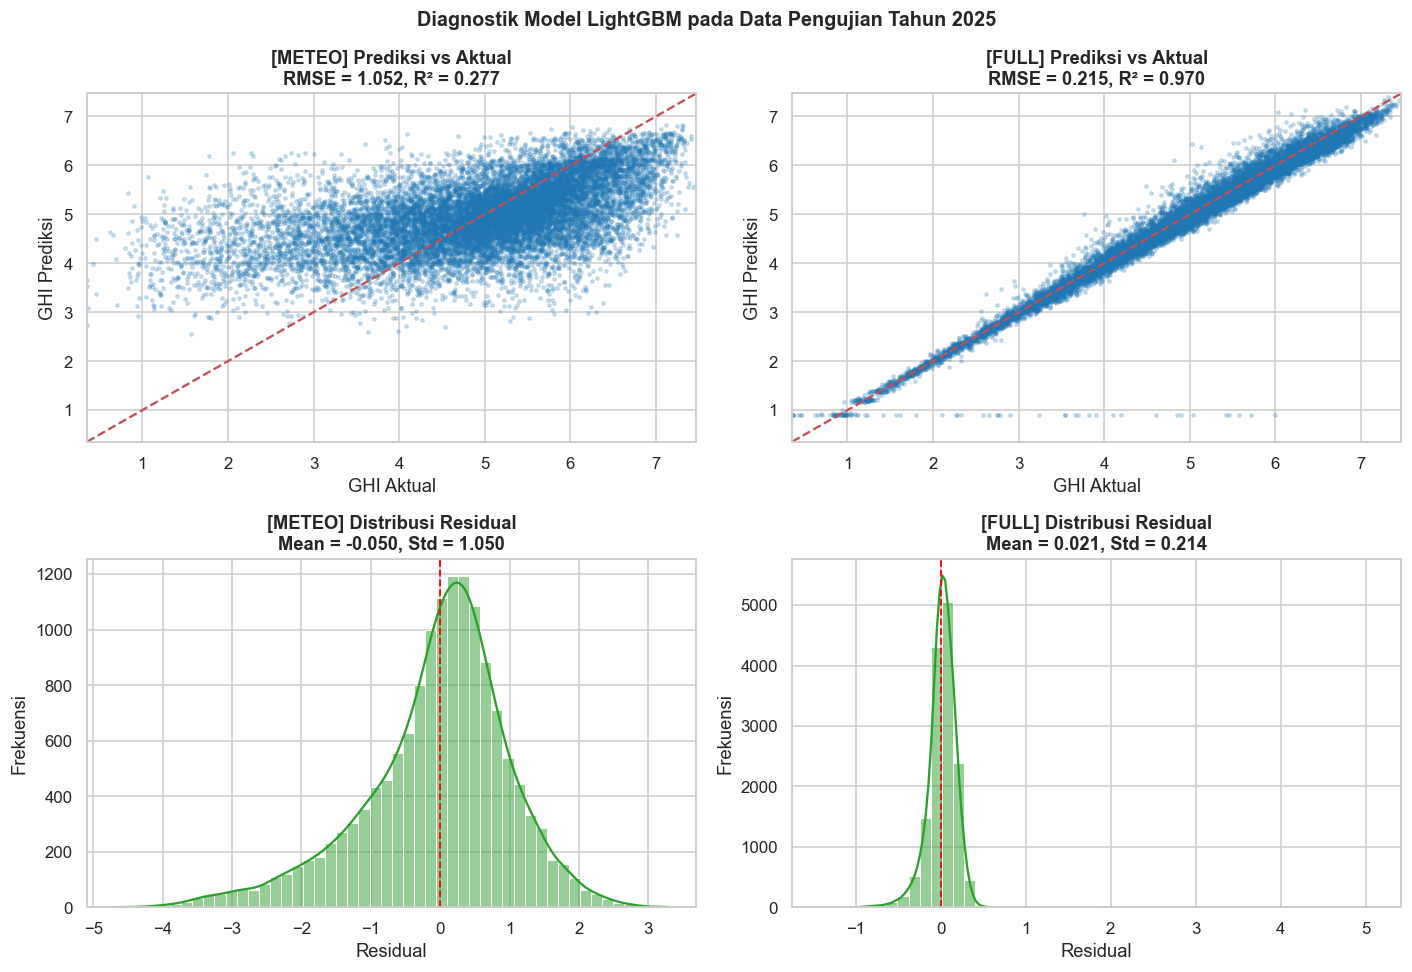

In [23]:
# Buat visualisasi diagnostik untuk setiap skenario
fig, axes = plt.subplots(
    2,
    len(results),
    figsize=(6.5 * len(results), 9),
)

# Penyesuaian apabila hanya terdapat satu skenario
if len(results) == 1:

    axes = axes.reshape(2, 1)


# Visualisasikan hasil setiap skenario
for column_index, (scenario_name, result) in enumerate(results.items()):

    # Nilai aktual dan prediksi
    y_true = result["y_test"]
    y_pred = result["pred_test"]

    # Hitung residual
    residual = (
        y_true
        - y_pred
    )

    # Tentukan batas sumbu yang sama
    axis_limit = [

        min(
            y_true.min(),
            y_pred.min(),
        ),

        max(
            y_true.max(),
            y_pred.max(),
        ),
    ]


    # Scatter plot aktual vs prediksi
    ax = axes[0, column_index]

    ax.scatter(

        y_true,
        y_pred,

        s=5,
        alpha=0.2,
        color="#1f77b4",
    )

    # Garis prediksi sempurna
    ax.plot(
        axis_limit,
        axis_limit,
        "r--",
        linewidth=1.5,
    )

    ax.set_xlim(axis_limit)
    ax.set_ylim(axis_limit)

    ax.set_title(
        f"[{scenario_name}] Prediksi vs Aktual\n"
        f"RMSE = {result['metrics_test']['RMSE']:.3f}, "
        f"R² = {result['metrics_test']['R2']:.3f}"
    )

    ax.set_xlabel("GHI Aktual")
    ax.set_ylabel("GHI Prediksi")


    # Histogram residual
    ax = axes[1, column_index]

    sns.histplot(

        residual,

        bins=50,
        kde=True,

        color="#2ca02c",

        ax=ax,
    )

    # Garis residual nol
    ax.axvline(
        0,
        color="red",
        linestyle="--",
        linewidth=1.2,
    )

    ax.set_title(
        f"[{scenario_name}] Distribusi Residual\n"
        f"Mean = {residual.mean():.3f}, "
        f"Std = {residual.std():.3f}"
    )

    ax.set_xlabel("Residual")
    ax.set_ylabel("Frekuensi")


# Tambahkan judul utama
fig.suptitle(
    "Diagnostik Model LightGBM pada Data Pengujian Tahun 2025",
    fontsize=13,
    fontweight="bold",
)

# Rapikan layout
plt.tight_layout()

# Tampilkan visualisasi
plt.show()

#### Analisis Feature Importance

Tahap ini bertujuan untuk menganalisis tingkat kontribusi setiap fitur terhadap proses prediksi model LightGBM. Nilai feature importance dihitung menggunakan metrik gain, yaitu total peningkatan fungsi objektif yang dihasilkan oleh suatu fitur selama pembentukan pohon keputusan. Semakin besar nilai gain, semakin besar pula kontribusi fitur tersebut dalam meningkatkan performa model.

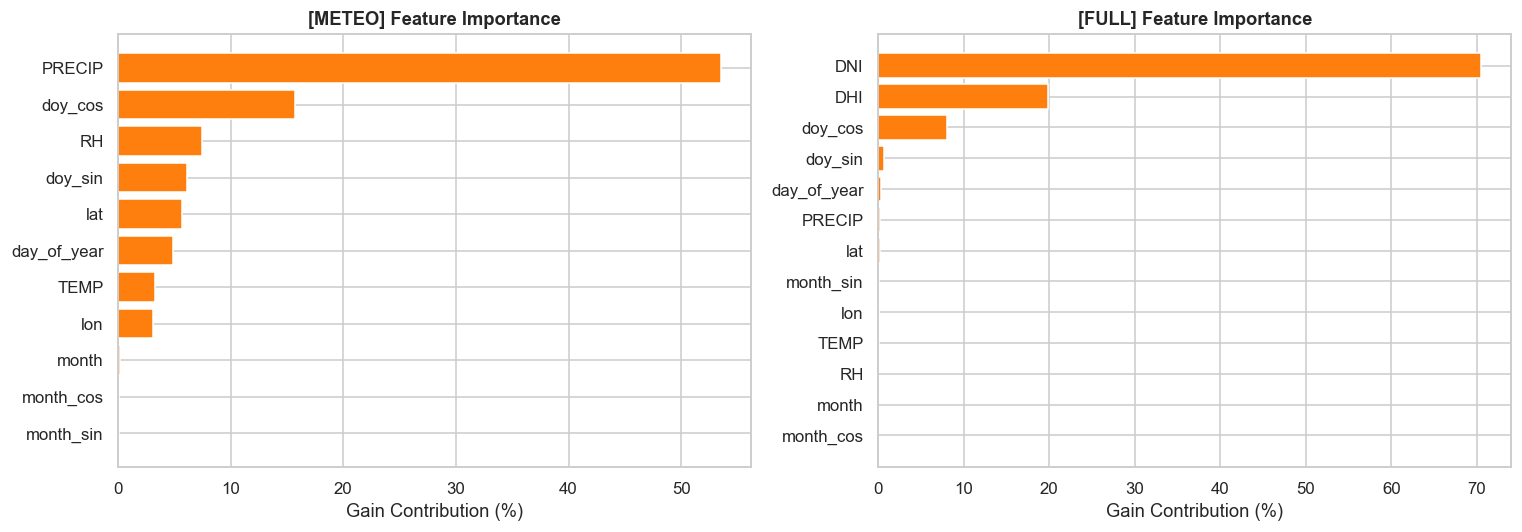

,feature,gain,gain_pct
0,DNI,3194683.55,70.53
1,DHI,898642.05,19.84
2,doy_cos,364092.39,8.04
3,doy_sin,30851.88,0.68
4,day_of_year,13990.83,0.31
5,PRECIP,7879.79,0.17
6,lat,7658.20,0.17
7,month_sin,5098.86,0.11
8,lon,2593.55,0.06
9,TEMP,2269.49,0.05


In [24]:
# Buat area visualisasi feature importance
fig, axes = plt.subplots(
    1,
    len(results),
    figsize=(7 * len(results), 5),
)

# Penyesuaian apabila hanya terdapat satu skenario
if len(results) == 1:

    axes = [axes]


# Menyimpan feature importance setiap skenario
feature_importance_tables = {}


# Visualisasikan feature importance setiap skenario
for ax, (scenario_name, result) in zip(
    axes,
    results.items(),
):

    # Hitung feature importance berdasarkan gain
    importance = pd.DataFrame({

        "feature": result["features"],

        "gain": (
            result["model"]
            .booster_
            .feature_importance(
                importance_type="gain",
            )
        ),
    })

    # Urutkan feature berdasarkan nilai gain
    importance = (
        importance
        .sort_values(
            "gain",
            ascending=True,
        )
    )

    # Hitung persentase kontribusi setiap feature
    importance["gain_pct"] = (

        importance["gain"]
        / importance["gain"].sum()
        * 100
    )

    # Simpan tabel feature importance
    feature_importance_tables[
        scenario_name
    ] = (

        importance
        .sort_values(
            "gain",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    # Visualisasikan feature importance
    ax.barh(

        importance["feature"],
        importance["gain_pct"],

        color="#ff7f0e",
    )

    ax.set_title(
        f"[{scenario_name}] Feature Importance"
    )

    ax.set_xlabel(
        "Gain Contribution (%)"
    )


# Rapikan layout
plt.tight_layout()

# Tampilkan visualisasi
plt.show()


# Tampilkan feature importance skenario FULL
display(
    feature_importance_tables["FULL"]
    .round(2)
)

#### Penyimpanan Model dan Hasil Eksperimen

Tahap terakhir bertujuan menyimpan seluruh artefak hasil pelatihan model agar dapat digunakan kembali pada proses evaluasi maupun implementasi sistem. Artefak yang disimpan meliputi model LightGBM dalam format native (.txt) dan pickle (.pkl), hasil prediksi pada data uji, metrik evaluasi, hyperparameter terbaik, serta nilai feature importance dalam format JSON. Penyimpanan artefak ini memastikan eksperimen dapat direproduksi dan model siap diintegrasikan ke dalam aplikasi prediksi.

In [25]:
# Nama algoritma yang digunakan
ALGORITHM = "lightgbm"


# Menyimpan seluruh hasil prediksi
prediction_frames = []

# Struktur JSON untuk menyimpan hasil eksperimen
experiment_results = {
    "algorithm": ALGORITHM,
    "random_state": RANDOM_STATE,
    "scenarios": {},
}


# Simpan artefak untuk setiap skenario
for scenario_name, artifact in results.items():

    # Simpan model native LightGBM
    model_txt_path = (
        DIR_MODELS /
        f"{ALGORITHM}_{scenario_name}.txt"
    )

    artifact["model"].booster_.save_model(
        str(model_txt_path)
    )

    # Simpan model sklearn (.pkl) untuk kebutuhan deployment
    model_pkl_path = (
        DIR_MODELS /
        f"{ALGORITHM}_{scenario_name}.pkl"
    )

    joblib.dump(
        artifact["model"],
        model_pkl_path,
    )

    # Simpan hasil prediksi data test
    prediction_result = (
        artifact["test_index"]
        .copy()
    )

    prediction_result["scenario"] = scenario_name
    prediction_result["y_true"] = artifact["y_test"]
    prediction_result["y_pred"] = artifact["pred_test"]

    prediction_frames.append(
        prediction_result
    )

    # Simpan ringkasan hasil eksperimen
    experiment_results["scenarios"][scenario_name] = {

        "features":
            artifact["features"],

        "best_params":
            artifact["best_params"],

        "best_iteration":
            artifact["best_iteration"],

        "cv_rmse":
            artifact["cv_rmse"],

        "metrics_train":
            artifact["metrics_train"],

        "metrics_test":
            artifact["metrics_test"],

        "model_file":
            model_txt_path.name,

        "model_pkl":
            model_pkl_path.name,

        "feature_importance_gain": (
            feature_importance_tables[scenario_name]
            .set_index("feature")["gain"]
            .round(2)
            .to_dict()
        ),
    }

    print(
        f"[OK] {scenario_name:<6}"
        f" -> {model_txt_path.name}"
        f" | {model_pkl_path.name}"
    )


# Gabungkan seluruh hasil prediksi
prediction_dataset = pd.concat(
    prediction_frames,
    ignore_index=True,
)

prediction_path = (
    DIR_RESULTS /
    f"{ALGORITHM}_predictions.csv"
)

prediction_dataset.to_csv(
    prediction_path,
    index=False,
)

print(
    f"\n[OK] Prediction"
    f" -> {prediction_path.name}"
)


# Simpan hasil eksperimen ke JSON
result_json_path = (
    DIR_RESULTS /
    f"{ALGORITHM}_results.json"
)

with open(
    result_json_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        experiment_results,
        file,
        indent=2,
    )

print(
    f"[OK] Result JSON"
    f" -> {result_json_path.name}"
)


# Tampilkan ringkasan metrik akhir
print("\nRingkasan performa model pada data test")

display(
    summary_metrics[
        [
            "test_rmse",
            "test_mae",
            "test_r2",
        ]
    ]
)

[OK] METEO  -> lightgbm_METEO.txt | lightgbm_METEO.pkl
[OK] FULL   -> lightgbm_FULL.txt | lightgbm_FULL.pkl

[OK] Prediction -> lightgbm_predictions.csv
[OK] Result JSON -> lightgbm_results.json

Ringkasan performa model pada data test


,test_rmse,test_mae,test_r2
scenario,,,
METEO,1.0516,0.7883,0.2765
FULL,0.2147,0.1278,0.9698
